In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [30]:
df = pd.read_csv("cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday


In [6]:
print(df.shape)

print(df.columns)

df.info()

(400916, 14)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day',
       'Hour', 'Weekday'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      400916 non-null  int64  
 1   StockCode    400916 non-null  object 
 2   Description  400916 non-null  object 
 3   Quantity     400916 non-null  int64  
 4   InvoiceDate  400916 non-null  object 
 5   Price        400916 non-null  float64
 6   Customer ID  400916 non-null  int64  
 7   Country      400916 non-null  object 
 8   TotalPrice   400916 non-null  float64
 9   Year         400916 non-null  int64  
 10  Month        400916 non-null  int64  
 11  Day          400916 non-null  int64  
 12  Hour         400916 non-null  int64  
 13  Weekday      400916 non-

In [7]:
df['TotalPrice'] = df['Quantity'] * df['Price']

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday


In [8]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True
)

df['InvoiceDate'].head()


,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2010-12-10 20:01:00


In [11]:
rfm = df.groupby('Customer ID').agg({

    'InvoiceDate': lambda x:
    (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'TotalPrice': 'sum'

})
rfm.head()

,InvoiceDate,Invoice,TotalPrice
Customer ID,,,
12346,165,11,372.86
12347,3,2,1323.32
12348,74,1,222.16
12349,43,3,2671.14
12351,11,1,300.93


In [12]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm = rfm.reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [13]:
print(rfm.columns)


Index(['Customer ID', 'Recency', 'Frequency', 'Monetary'], dtype='object')


In [14]:
rfm['R_score'] = pd.qcut(
rfm['Recency'],
5,
labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
rfm['Frequency'].rank(method='first'),
5,
labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
rfm['Monetary'],
5,
labels=[1,2,3,4,5]
)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346,165,11,372.86,2,5,2
1,12347,3,2,1323.32,5,2,4
2,12348,74,1,222.16,2,1,1
3,12349,43,3,2671.14,3,3,5
4,12351,11,1,300.93,5,1,2


In [15]:

rfm['RFM_Score']=(

rfm['R_score'].astype(str)+
rfm['F_score'].astype(str)+
rfm['M_score'].astype(str)

)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


In [16]:
features=rfm[[
'Recency',
'Frequency',
'Monetary'
]]
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


In [17]:
scaler=StandardScaler()

scaled=scaler.fit_transform(
features
)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


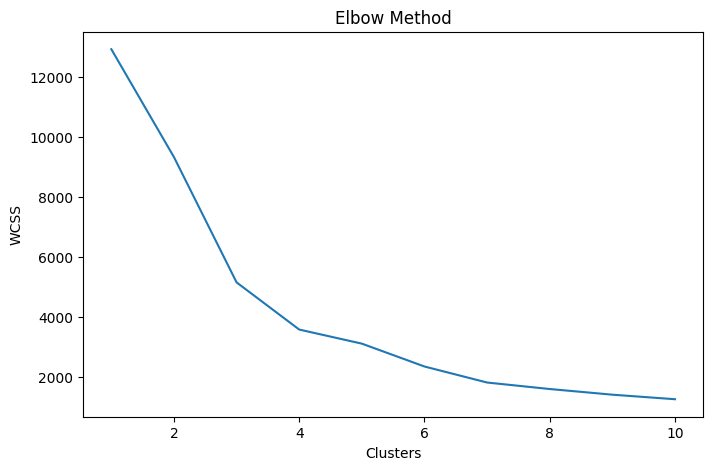

In [18]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
    n_clusters=i,
    random_state=42
    )

    kmeans.fit(scaled)

    wcss.append(
    kmeans.inertia_
    )


plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [19]:
kmeans=KMeans(
n_clusters=4,
random_state=42
)

rfm['Cluster']=kmeans.fit_predict(
scaled
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster
0,12346,165,11,372.86,2,5,2,252,1
1,12347,3,2,1323.32,5,2,4,524,0
2,12348,74,1,222.16,2,1,1,211,0
3,12349,43,3,2671.14,3,3,5,335,0
4,12351,11,1,300.93,5,1,2,512,0


In [20]:
cluster_summary = rfm.groupby('Cluster')[

['Recency',
 'Frequency',
 'Monetary']

].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.031835,4.455056,1710.650030
1,242.976122,1.659981,593.540319
2,5.600000,113.600000,215535.000000
3,14.910714,47.017857,28896.416661


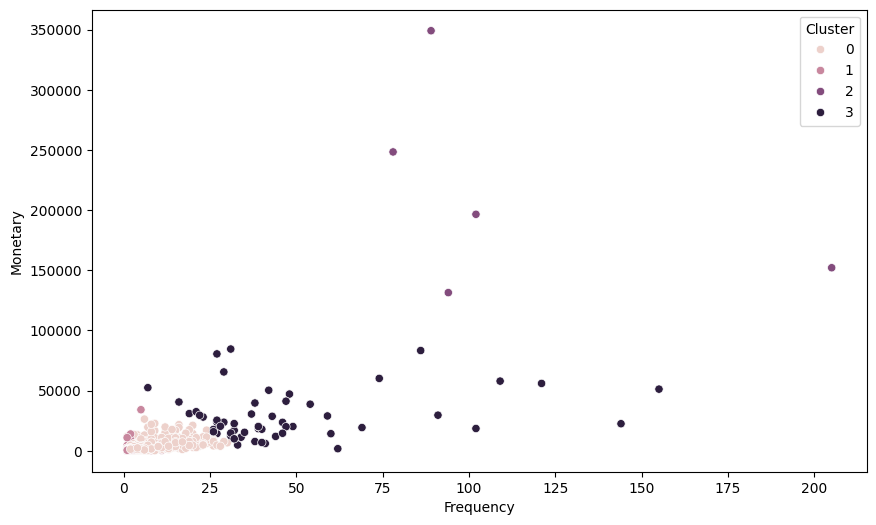

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(

data=rfm,

x='Frequency',
y='Monetary',

hue='Cluster'

)

plt.show()

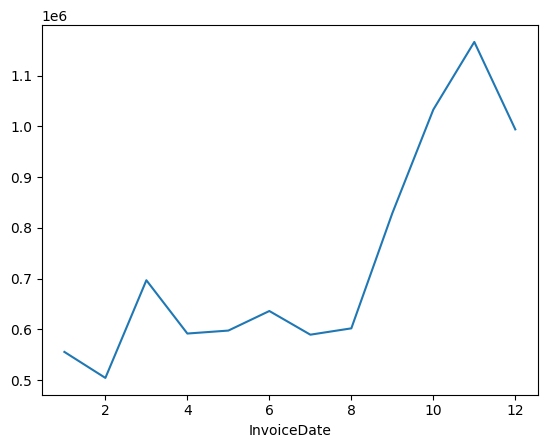

In [22]:
monthly=df.groupby(
df['InvoiceDate'].dt.month
)['TotalPrice'].sum()

monthly.plot()

plt.show()

In [23]:
rfm['Churn']=(
rfm['Recency']>90
).astype(int)

In [24]:
X=rfm[[
'Recency',
'Frequency',
'Monetary'
]]

y=rfm['Churn']

In [25]:
X_train,X_test,y_train,y_test=\
train_test_split(

X,
y,

test_size=.2,

random_state=42
)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster,Churn
0,12346,165,11,372.86,2,5,2,252,1,1
1,12347,3,2,1323.32,5,2,4,524,0,0
2,12348,74,1,222.16,2,1,1,211,0,0
3,12349,43,3,2671.14,3,3,5,335,0,0
4,12351,11,1,300.93,5,1,2,512,0,0


In [26]:
model=XGBClassifier()

model.fit(
X_train,
y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [27]:
pred=model.predict(
X_test
)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster,Churn
0,12346,165,11,372.86,2,5,2,252,1,1
1,12347,3,2,1323.32,5,2,4,524,0,0
2,12348,74,1,222.16,2,1,1,211,0,0
3,12349,43,3,2671.14,3,3,5,335,0,0
4,12351,11,1,300.93,5,1,2,512,0,0


In [28]:
print(
classification_report(
y_test,
pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       571
           1       1.00      1.00      1.00       292

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



In [32]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour', 'Weekday']


In [34]:
rfm.to_csv(
"customer_segments.csv",
index=False
)

In [35]:
rfm.to_csv(
"customer_churn_results.csv",
index=False
)

In [36]:
from google.colab import files

files.download(
"customer_segments.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
plt.savefig(
"cluster_plot.png",
bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>